# movie genre prediction model

## about

The main idea of this model is to take a movie, chop it into smaller chunks that can be processed by the ai. Than put the chunks into the model and calculate the average genre over them. This should result in a useable genre predicting ai model.

## problems

The biggest problem is the dataset. My current dataset consists of ~1.5TB of movies. That is less than its is needed for a good quality model bit its enough. The size of the data makes the processing very slow.

## ai parameters

The ai input will be:

- motion between the frames (catch fast car scenes, fights or slow scenes)
- full audio of the frame (to catch guns/bombs, horror jumpscares or calm music etc...)
- average of the clips brightness (horrors are dark, romance movies are bright)
- average clip color (same use as clip brightness)

The ai output will than be:

- list of propabilities of genres each movie has multiple genres so the ai will output multiple values

---


## čsfd scraping

First the movies need to be matched with the correct genres. This is done through a javascript open source project which can be fond [here](https://github.com/bartholomej/node-csfd-api).
The script i used for matching the genres can be found [here](../scraper/scraper.js).

---


## data chopping

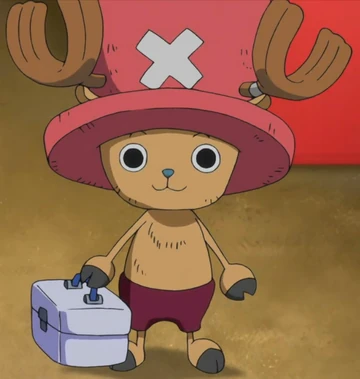

Thirst the movies are split into ~10 minute clips. This is done to reduse the ammount of parameter inputs of the ai model. For the splitting the python-python-ffmpeg library is used. Some movies had problems with the `-copy` parameter so when the copy fails a whole reencode is done. The reencode is on the fastest settings, this reduces quality but it makes the process faster.

---


The movie name needs the be stripped of all non ascii characters, because ffmpeg does not like them. Non ascii characters should not affect the encoding but it did cause some problems and ffmpeg crashes.

In [1]:
import re

def safe_name(name):
    return re.sub(r'[^\w\-_\. ]', '_', name)

Here are some helper functions to convert arrays into columns to better expand values into dataframes.

In [2]:
def array_to_columns(arr, name):
    return {f"{name}_{i}": val for i, val in enumerate(arr)}

def array_2d_to_columns(arr, name):
    flat_dict = {}
    for i, row in enumerate(arr):
        for j, val in enumerate(row):
            flat_dict[f"{name}_{i}_{j}"] = val
    return flat_dict

This function does the actual chopping. It takes the video path and output pattern. The output pattern is from ffmpeg, it allows to make one pattern for all the clips. The clip duration can be also changed but its set to 10 minutes by default.

In [3]:
import ffmpeg
import os
import glob

def chop_video(video_path, output_pattern, clip_duration=600):
    pattern_check = output_pattern.replace("%03d", "*")
    existing_clips = glob.glob(pattern_check)

    if existing_clips:
        return "exists"

    # stream copy
    try:
        (
            ffmpeg
            .input(video_path)
            .output(
                output_pattern,
                c='copy',
                f='segment',
                segment_time=clip_duration,
                reset_timestamps=1
            )
            .overwrite_output()
            .run(quiet=True)
        )
        return "copy"
    except ffmpeg.Error:
        pass

    # reencode if copy fails
    try:
        (
            ffmpeg
            .input(video_path)
            .output(
                output_pattern,
                vcodec='libx264',
                preset='ultrafast',
                crf=28,
                acodec='aac',
                audio_bitrate='128k',
                f='segment',
                segment_time=clip_duration,
                reset_timestamps=1
            )
            .overwrite_output()
            .run(quiet=True)
        )
        return "reencode"
    except ffmpeg.Error:
        return None

Chop the whole movie. This function takes the root directory, that is where the movie is placed. Than the output directory, that is where to put the new video clips.

In [4]:
import os
import pandas as pd

def process_chop(movie, root_dir, output_dir):
    print(f"chopping: {movie['file_path']}")
    safe_title = safe_name(movie['title'])
    dir_name = f"{safe_title} ({movie['year']})"
    dir_path = os.path.join(output_dir, dir_name)
    os.makedirs(dir_path, exist_ok=True)

    video_input = os.path.join(root_dir, movie['file_path'])
    if not os.path.isfile(video_input):
        print(f"video not found: {video_input}")
        return pd.DataFrame()

    output_pattern = os.path.join(dir_path, f"{safe_title}_{movie['year']}_%03d.mkv")

    result = chop_video(video_input, output_pattern)
    if result == "copy":
        print(f"stream copy: {movie['title']}")
    elif result == "reencode":
        print(f"reencode: {movie['title']}")
    elif result == "exists":
        print(f"clips exist: {movie['title']}")
    else:
        print(f"failed {movie['title']}")
        return pd.DataFrame()

    video_extensions = (".mkv", ".mp4", ".mov", ".avi", ".flv", ".wmv", ".m4v", ".webm")
    clips = sorted(
        f for f in os.listdir(dir_path)
        if os.path.isfile(os.path.join(dir_path, f)) and f.lower().endswith(video_extensions)
    )

    entries = pd.DataFrame()
    
    for clip_file in clips:
        clip_path_rel = os.path.relpath(os.path.join(dir_path, clip_file), output_dir)
        entry = {
            "csfd_id": movie["csfd_id"],
            "title": movie["title"],
            "year": movie["year"],
            "genres": movie["genres"],
            "clip_path": clip_path_rel
        }
        
        entries = pd.concat([entries, pd.DataFrame([entry])], ignore_index=True)

    return entries

## data extraction

When the video is chopped into smaller clips. The data extraction can start.

Each video clip is again split into 32 smaller segments. And some average values are calculated on these segments.

---


This function calculates the motion, brightness and average color of each segment. It outputs a dataframe that contains all the data.

In [5]:
import cv2

# enable gpu acceleration
cv2.ocl.setUseOpenCL(True)

def process_video(video_clip, root_dir, width=256, height=144, segments=32):
    print(f"processing video: {video_clip['clip_path']}")
    video_path = os.path.join(root_dir, video_clip["clip_path"])
    
    capture = cv2.VideoCapture(video_path)
    if not capture.isOpened():
        raise RuntimeError(f"cannot open video: {video_path}")

    total_frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= segments:
        frames_to_check = list(range(total_frames))
    else:
        step = total_frames / (segments)
        frames_to_check = [int(i * step) for i in range(segments + 1)]

    motion_values = []
    brightness_values = []
    avg_color_values = []

    prev_gray = None

    for frame_idx in frames_to_check:
        capture.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = capture.read()
        if not ret:
            break

        frame = cv2.resize(frame, (width, height))
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # motion
        if prev_gray is not None:
            diff = cv2.absdiff(prev_gray, gray)
            motion_values.append(float(diff.mean()))
        else:
            motion_values.append(0.0)

        # brightness
        brightness_values.append(float(gray.mean()))

        # avg color
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mean_bgr = frame.mean(axis=(0, 1))
        avg_color_values.append((
            float(mean_bgr[2]),
            float(mean_bgr[1]),
            float(mean_bgr[0])
        ))

        prev_gray = gray

    capture.release()

    row_data = {
        **array_to_columns(motion_values, "motion"),
        **array_to_columns(brightness_values, "brightness"),
        **array_2d_to_columns(avg_color_values, "color")
    }

    df = pd.DataFrame([row_data])
    return df


This function extracts audio data of the segments. The extracted values are rmd, amplitude and mfcc.

In [6]:
import ffmpeg
import librosa
import numpy as np

def process_audio(video_clip, root_dir, segments=32, sample_rate=8000):
    print(f"processing audio: {video_clip['clip_path']}")
    video_path = os.path.join(root_dir, video_clip["clip_path"])

    out, _ = (
        ffmpeg
        .input(video_path)
        .output('pipe:', format='f32le', acodec='pcm_f32le', ac=1, ar=sample_rate)
        .run(capture_stdout=True, capture_stderr=True)
    )
    
    y = np.frombuffer(out, np.float32)
    total_samples = len(y)
    
    segment_size = total_samples // segments
    rms_values = []
    amp_values = []
    mfcc_values = []
    
    for i in range(segments):
        start = i * segment_size
        end = start + segment_size if i < segments - 1 else total_samples
        segment = y[start:end]
        
        rms = np.sqrt(np.mean(segment**2))
        amp_mean = np.mean(np.abs(segment))
        mfccs = librosa.feature.mfcc(y=segment, sr=sample_rate, n_mfcc=13)
        mfcc_mean = np.mean(mfccs, axis=1)
        
        rms_values.append(rms)
        amp_values.append(amp_mean)
        mfcc_values.append(mfcc_mean)
    
    row_data = {
        **array_to_columns(amp_values, "amp"),
        **array_to_columns(rms_values, "rms"),
        **array_2d_to_columns(mfcc_values, "mfcc")
    }

    df = pd.DataFrame([row_data])
    return df

## process pipeline

Now when all the functions that process movies are defined they can be put into a pipeline that processes all movies.

The process pipeline takes all movies and datasets and chops them into smaller clips. Audio and video data is than processed from these clips and all of the data is stored in a dataframe.

---


Process one movie.

In [7]:
def process_movie(movie, root_dir, output_dir):
    chopped = process_chop(movie.to_dict(), root_dir, output_dir)

    all_rows = []
    for _, clip in chopped.iterrows():
        video = process_video(clip, output_dir)
        audio = process_audio(clip, output_dir)

        clip_dict = clip.to_dict()
        video_dict = video.iloc[0].to_dict()
        audio_dict = audio.iloc[0].to_dict()

        merged_row = {**clip_dict, **video_dict, **audio_dict}

        all_rows.append(merged_row)
    return pd.DataFrame(all_rows)


Process a list of movies.

In [8]:
def process_dataset(movie_data):
    dataset = data["dataset"]
    root_dir = data["root_dir"]
    output_dir = data["output_dir"]
    
    dataframes = []

    for _, movie in dataset.iterrows():
        dataframes.append(process_movie(movie, root_dir, output_dir))
    
    return pd.concat(dataframes, ignore_index=True)


Take all movie paths, scraped datasets and process them.

In [ ]:
import pandas as pd
import numpy as np

movie_data = [
    {
        "dataset":"/mnt/hdd/data/datasets/drive1_Milan.jsonl",
        "root_dir":"/mnt/drive/Milan/",
        "output_dir":"/mnt/drive3/data/videos/drive1_Milan/"
    },
    {
        "dataset":"/mnt/hdd/data/datasets/drive1_Milan_1.jsonl",
        "root_dir":"/mnt/drive/Milan 1/",
        "output_dir":"/mnt/drive3/data/videos/drive1_Milan_1/"
    },
    {
        "dataset":"/mnt/hdd/data/datasets/drive1_Tadikovi.jsonl",
        "root_dir":"/mnt/drive/Tadíkovi/",
        "output_dir":"/mnt/hdd/data/videos/drive1_Tadikovi/"
    },
    {
        "dataset":"/mnt/hdd/data/datasets/drive1_Woody_Alen.jsonl",
        "root_dir":"/mnt/drive/Woody Alen/",
        "output_dir":"/mnt/drive3/data/videos/drive1_Woody_Alen/"
    },
    {
        "dataset":"/mnt/hdd/data/datasets/drive1_dobre_filmy.jsonl",
        "root_dir":"/mnt/drive/dobré filmy/",
        "output_dir":"/mnt/hdd/data/videos/drive1_dobre_filmy/"
    },
    {
        "dataset":"/mnt/hdd/data/datasets/drive2_filmy.jsonl",
        "root_dir":"/mnt/drive/Filmy/",
        "output_dir":"/mnt/drive3/data/videos/drive2_filmy/"
    },
    {
        "dataset":"/mnt/hdd/data/datasets/drive3_leden_2026_pak_smaz.jsonl",
        "root_dir":"/mnt/drive2/leden 2026, pak smaž/",
        "output_dir":"/mnt/drive3/data/videos/drive3_leden_2026_pak_smaz/"
    },
]

for data in movie_data:
    file = open(data["dataset"], "r", encoding="utf-8")
    data["dataset"] = pd.read_json(file, lines=True)
    file.close()

dataframes = []

for i, data in enumerate(movie_data):
    print(f"{i}/{len(movie_data)}")

    dataframes.append(process_dataset(data))

dataset = pd.concat(dataframes, ignore_index=True)

# save the dataset!!!!!!
dataset.to_json('dataset.jsonl', orient='records', lines=True)

Now load the dataset and start the machine learning.

In [251]:
import pandas as pd

file = open("dataset.jsonl", "r", encoding="utf-8")
dataset = pd.read_json(file, lines=True)
file.close()

In [252]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
import re

def prepare_dataset_X(dataset):
    X = dataset.drop(columns=[
    'genres', 'genre_single', 'title', 'clip_path'
    ], errors='ignore')

    X = X.select_dtypes(include=[np.number])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_scaled = np.nan_to_num(X_scaled)

    return X_scaled
    
def prepare_dataset_y(dataset):
    dataset['genres'] = dataset['genres'].apply(
        lambda genre_list: [
            g.strip()
            for item in genre_list
            for g in re.split(r'\s+', item)
            if g.strip()
        ]
    )

    print(dataset['genres'])

    mlb = MultiLabelBinarizer()
    y = mlb.fit_transform(dataset['genres'])

    return y, mlb

In [253]:
from sklearn.model_selection import train_test_split

X = prepare_dataset_X(dataset)
y, mlb = prepare_dataset_y(dataset)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

0       [Thriller, Drama, Akční, Krimi]
1       [Thriller, Drama, Akční, Krimi]
2       [Thriller, Drama, Akční, Krimi]
3       [Thriller, Drama, Akční, Krimi]
4       [Thriller, Drama, Akční, Krimi]
                     ...               
2733               [Drama, Životopisný]
2734               [Drama, Životopisný]
2735               [Drama, Životopisný]
2736               [Drama, Životopisný]
2737               [Drama, Životopisný]
Name: genres, Length: 2738, dtype: object


In [254]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_dim = X_train.shape[1]
output_dim = y.shape[1]

model = models.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(1024),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'),

    # Output
    layers.Dense(output_dim, activation='sigmoid')
])

In [255]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [256]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8523 - loss: 0.3378 - precision: 0.2670 - recall: 0.1990 - val_accuracy: 0.8935 - val_loss: 0.3044 - val_precision: 0.5040 - val_recall: 0.3314
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8995 - loss: 0.2375 - precision: 0.5879 - recall: 0.2783 - val_accuracy: 0.9081 - val_loss: 0.2354 - val_precision: 0.5974 - val_recall: 0.4360
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9040 - loss: 0.2264 - precision: 0.6147 - recall: 0.3330 - val_accuracy: 0.9122 - val_loss: 0.2215 - val_precision: 0.6278 - val_recall: 0.4430
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9090 - loss: 0.2148 - precision: 0.6350 - recall: 0.3980 - val_accuracy: 0.9145 - val_loss: 0.2096 - val_precision: 0.6328 - val_recall: 0.4800
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9124 - loss: 0.2087 - precision: 0.6510 - recall: 0.4329 - val_accuracy: 0.9128 - val_loss: 0.2124 

In [257]:
model.evaluate(X_test, y_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9285 - loss: 0.1910 - precision: 0.6907 - recall: 0.6011 


[0.1909930557012558, 0.9284546375274658, 0.69074946641922, 0.6010575890541077]

In [259]:
from sklearn.metrics import f1_score

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.3).astype(int)

f1 = f1_score(y_test, y_pred, average='micro')
print("F1:", f1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
F1: 0.6529492455418381


In [262]:
movie_index = 290
movie_input = X[movie_index].reshape(1, -1)
pred_probs = model.predict(movie_input)
pred_labels = (pred_probs >= 0.5).astype(int)

predicted_genres = [genre for i, genre in enumerate(mlb.classes_) if pred_labels[0][i] == 1]

print(f"movie: {dataset.iloc[movie_index]['title']}")
print(f"genres: {dataset.iloc[movie_index]['genres']}")

print("predicted genres:", predicted_genres)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Movie: Neřízená střela
Genres: ['Akční', 'Komedie', 'Drama', 'Krimi']
Predicted genres: ['Akční', 'Drama', 'Komedie', 'Krimi']


In [266]:
import pickle

model.save("model.keras")

with open("mlb.pkl", "wb") as f:
    pickle.dump(mlb, f)